# 📓 Waveform Simulations

This notebook is meant to simulate and visualize various DSP waveform types, commonly used in sonar systems.

## ⚙️ Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Utilities ----------
def plot_time_domain(t, signal, title="Signal in Time Domain", xlabel="Time (s)", ylabel="Amplitude"):
    plt.figure(figsize=(10, 4))
    plt.plot(t, np.real(signal), label='Real')
    plt.plot(t, np.imag(signal), label='Imaginary', linestyle='--')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_frequency_domain(signal, fs, title="Frequency Spectrum", log_scale=False):
    N = len(signal)
    freqs = np.fft.fftfreq(N, d=1/fs)
    spectrum = np.fft.fft(signal)
    magnitude = np.abs(spectrum)

    plt.figure(figsize=(10, 4))
    if log_scale:
        plt.semilogy(freqs[:N//2], magnitude[:N//2])
    else:
        plt.plot(freqs[:N//2], magnitude[:N//2])
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---------- Waveform Generators ----------
def generate_lfm_chirp(duration, fs, f0, f1):
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    k = (f1 - f0) / duration
    phase = 2 * np.pi * (f0 * t + 0.5 * k * t**2)
    return t, np.exp(1j * phase)

def generate_barker_code(code):
    return np.array(code, dtype=np.float32)

def generate_step_fm_waveform(duration, fs, freqs):
    n_steps = len(freqs)
    step_duration = duration / n_steps
    samples_per_step = int(fs * step_duration)
    waveform = np.array([], dtype=np.complex64)

    for f in freqs:
        t = np.linspace(0, step_duration, samples_per_step, endpoint=False)
        wave = np.exp(1j * 2 * np.pi * f * t)
        waveform = np.concatenate((waveform, wave))

    return waveform


## 🔹 LFM Chirp

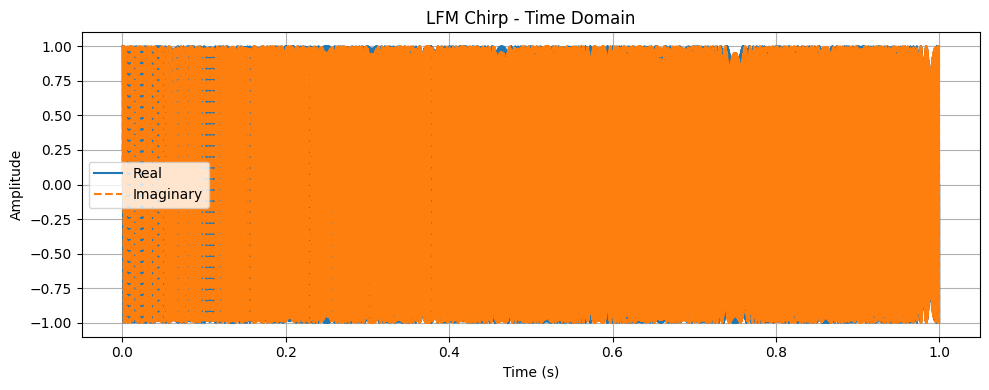

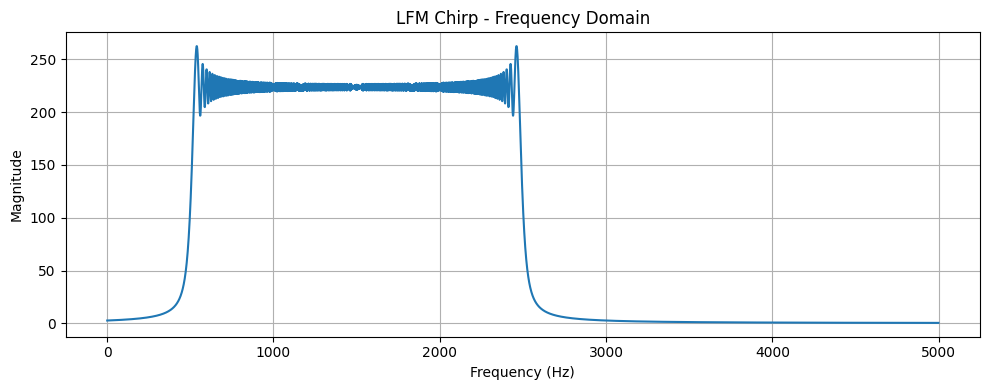

In [2]:
fs = 10000
duration = 1.0
f0, f1 = 500, 2500

t, chirp = generate_lfm_chirp(duration, fs, f0, f1)
plot_time_domain(t, chirp, title="LFM Chirp - Time Domain")
plot_frequency_domain(chirp, fs, title="LFM Chirp - Frequency Domain")

## 🔹 Barker Code

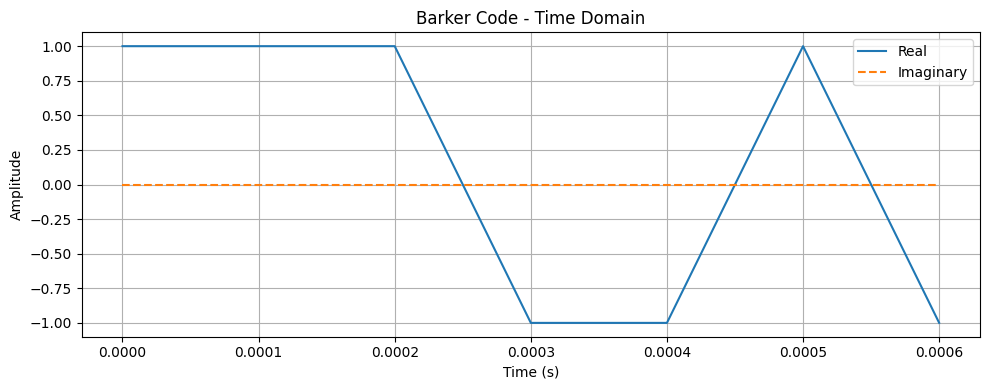

In [3]:
barker_seq = [+1, +1, +1, -1, -1, +1, -1]
barker_waveform = generate_barker_code(barker_seq)
t_barker = np.arange(len(barker_waveform)) / fs

plot_time_domain(t_barker, barker_waveform, title="Barker Code - Time Domain")

## 🔹 Step-FM Waveform

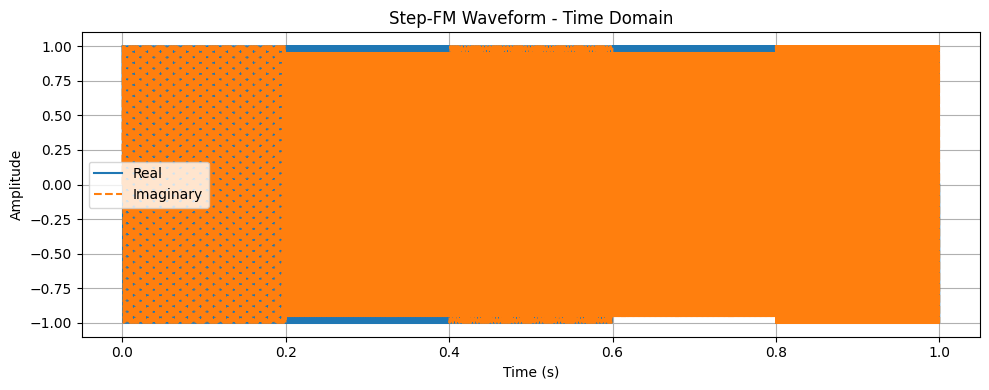

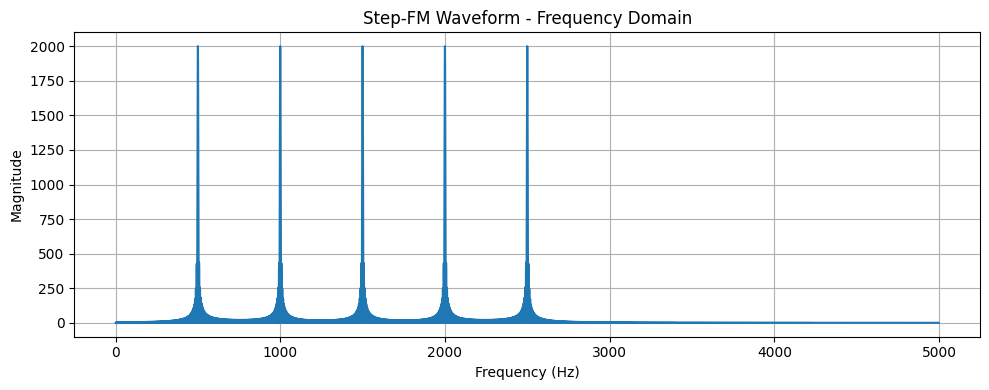

In [4]:
step_freqs = [500, 1000, 1500, 2000, 2500]
step_fm = generate_step_fm_waveform(duration, fs, step_freqs)
t_step = np.linspace(0, duration, len(step_fm), endpoint=False)

plot_time_domain(t_step, step_fm, title="Step-FM Waveform - Time Domain")
plot_frequency_domain(step_fm, fs, title="Step-FM Waveform - Frequency Domain")